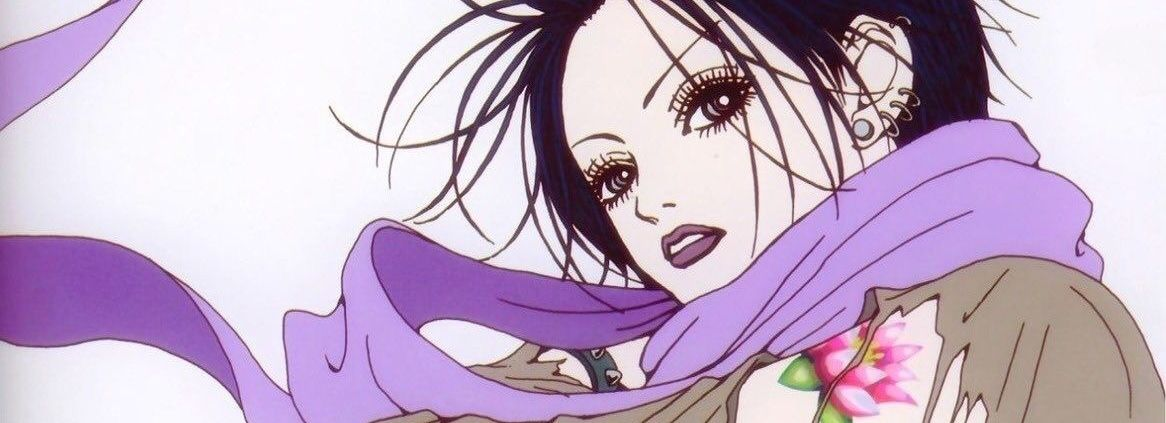

# Importando Bibliotecas

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

# Dados

In [2]:
df = pd.read_csv('Classified Data', index_col=0)

In [3]:
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


# Padronizar as Variáveis

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
scaler = StandardScaler()

In [6]:
scaler.fit(df.drop('TARGET CLASS', axis=1))

StandardScaler()

In [7]:
scaled_features = scaler.transform(df.drop('TARGET CLASS', axis = 1))

In [8]:
scaled_features

array([[-0.12354188,  0.18590747, -0.91343069, ..., -1.48236813,
        -0.9497194 , -0.64331425],
       [-1.08483602, -0.43034845, -1.02531333, ..., -0.20224031,
        -1.82805088,  0.63675862],
       [-0.78870217,  0.33931821,  0.30151137, ...,  0.28570652,
        -0.68249379, -0.37784986],
       ...,
       [ 0.64177714, -0.51308341, -0.17920486, ..., -2.36249443,
        -0.81426092,  0.11159651],
       [ 0.46707241, -0.98278576, -1.46519359, ..., -0.03677699,
         0.40602453, -0.85567   ],
       [-0.38765353, -0.59589427, -1.4313981 , ..., -0.56778932,
         0.3369971 ,  0.01034996]], shape=(1000, 10))

In [9]:
df_feat = pd.DataFrame(scaled_features, columns=df.columns[:-1])

In [10]:
df.columns[:-1]

Index(['WTT', 'PTI', 'EQW', 'SBI', 'LQE', 'QWG', 'FDJ', 'PJF', 'HQE', 'NXJ'], dtype='str')

In [11]:
df_feat.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


# Train Test Split

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df_feat
y = df['TARGET CLASS']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

# KNN

In [15]:
from sklearn.neighbors import KNeighborsClassifier

In [16]:
knn = KNeighborsClassifier(n_neighbors=1)

In [17]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [18]:
pred = knn.predict(X_test)

In [19]:
pred

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0])

# Previsões e Avaliações

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

In [21]:
print(confusion_matrix(y_test,pred))
print(classification_report(y_test, pred))

[[151   8]
 [ 15 126]]
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       159
           1       0.94      0.89      0.92       141

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



# Escolhendo um valor de K

In [22]:
error_rate = []

# Will take some time
for i in range(1,40):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

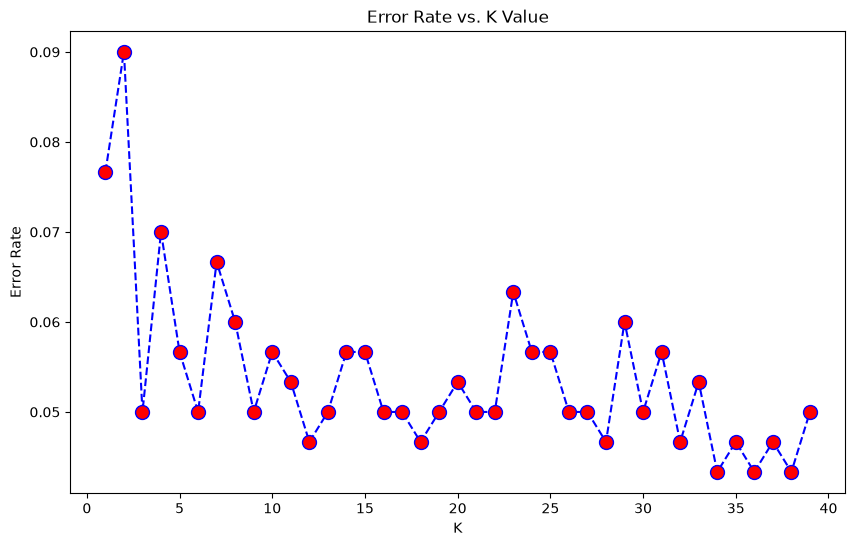

In [23]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [24]:
knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test, pred))

[[153   6]
 [  9 132]]


              precision    recall  f1-score   support

           0       0.94      0.96      0.95       159
           1       0.96      0.94      0.95       141

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



---

# Correção do Código 

---

# Importando bibliotecas e carregando os dados

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv("Classified Data", index_col=0)
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


# EDA

In [26]:
print("Formato (linhas, colunas):", df.shape)
print("\n--- Info ---")
df.info()

print("\n--- Valores ausentes por coluna ---")
print(df.isnull().sum())

print("\n--- Balanceamento da classe alvo ---")
print(df['TARGET CLASS'].value_counts())
print(df['TARGET CLASS'].value_counts(normalize=True).round(3))

print("\n--- Estatísticas descritivas ---")
df.describe().round(3)

Formato (linhas, colunas): (1000, 11)

--- Info ---


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   WTT           1000 non-null   float64
 1   PTI           1000 non-null   float64
 2   EQW           1000 non-null   float64
 3   SBI           1000 non-null   float64
 4   LQE           1000 non-null   float64
 5   QWG           1000 non-null   float64
 6   FDJ           1000 non-null   float64
 7   PJF           1000 non-null   float64
 8   HQE           1000 non-null   float64
 9   NXJ           1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB

--- Valores ausentes por coluna ---
WTT             0
PTI             0
EQW             0
SBI             0
LQE             0
QWG             0
FDJ             0
PJF             0
HQE             0
NXJ             0
TARGET CLASS    0
dtype: int64

--- Balanceamento da classe alvo ---
TARGET C

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.0
mean,0.950,1.114,0.834,0.682,1.032,0.944,0.963,1.072,1.158,1.363,0.5
std,0.290,0.257,0.292,0.230,0.243,0.256,0.255,0.289,0.294,0.204,0.5
min,0.174,0.441,0.171,0.045,0.315,0.262,0.295,0.299,0.365,0.640,0.0
25%,0.742,0.942,0.615,0.515,0.871,0.761,0.784,0.866,0.934,1.223,0.0
50%,0.940,1.118,0.813,0.677,1.036,0.942,0.945,1.066,1.166,1.375,0.5
75%,1.163,1.308,1.028,0.834,1.198,1.123,1.135,1.283,1.383,1.505,1.0
max,1.722,1.834,1.723,1.635,1.650,1.667,1.713,1.785,1.886,1.894,1.0


# Train Test Split

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop('TARGET CLASS', axis=1)
y = df['TARGET CLASS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=101,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

print("\nProporção das classes no treino:")
print(y_train.value_counts(normalize=True).round(3))
print("\nProporção das classes no teste:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (700, 10)
X_test:  (300, 10)
y_train: (700,)
y_test:  (300,)

Proporção das classes no treino:
TARGET CLASS
0    0.5
1    0.5
Name: proportion, dtype: float64

Proporção das classes no teste:
TARGET CLASS
1    0.5
0    0.5
Name: proportion, dtype: float64


# Padronizar as Variáveis

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit: aprende média e desvio SOMENTE com o treino
scaler.fit(X_train)

# transform: aplica nos dois conjuntos, com as estatísticas do treino
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# reconstruindo DataFrames para manter os nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("--- Treino padronizado: média e desvio ---")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))

print("\n--- Teste padronizado: média e desvio ---")
print(X_test_scaled.describe().loc[['mean', 'std']].round(3))

X_train_scaled.head()

--- Treino padronizado: média e desvio ---
        WTT    PTI    EQW    SBI    LQE    QWG    FDJ    PJF    HQE    NXJ
mean -0.000 -0.000  0.000 -0.000 -0.000 -0.000 -0.000 -0.000 -0.000  0.000
std   1.001  1.001  1.001  1.001  1.001  1.001  1.001  1.001  1.001  1.001

--- Teste padronizado: média e desvio ---
        WTT    PTI    EQW    SBI    LQE    QWG    FDJ    PJF    HQE    NXJ
mean  0.086 -0.002 -0.006 -0.026  0.125  0.036 -0.006  0.042 -0.038  0.088
std   0.952  0.999  0.996  1.041  1.034  1.036  0.993  0.977  0.963  0.929


,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
632,-0.961515,-0.488609,-0.343747,-1.483777,0.001314,1.224114,1.393402,-0.022190,-0.968507,0.442803
313,1.463387,-0.291326,2.149427,1.582063,1.449100,1.947912,-1.718494,0.379113,-1.278477,-1.173315
53,1.177179,0.112956,-1.021670,-0.061438,-1.022250,-0.378546,-1.242386,-1.004243,1.092746,-0.292457
598,1.255373,-0.396102,0.328689,-0.893990,-0.929888,-1.255340,-0.246801,-0.861428,1.077423,0.275326
69,0.921795,0.051309,-0.166815,-0.806071,1.427581,0.104857,-1.435429,0.511195,-0.406718,0.901076


# KNN com K = 1

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_scaled, y_train)

pred1 = knn1.predict(X_test_scaled)

print("WITH K=1\n")
print("Matriz de confusão:")
print(confusion_matrix(y_test, pred1))

print("\nClassification report:")
print(classification_report(y_test, pred1))

WITH K=1

Matriz de confusão:
[[136  14]
 [ 17 133]]

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       150
           1       0.90      0.89      0.90       150

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300



# Escolhendo K com Validação Cruzada

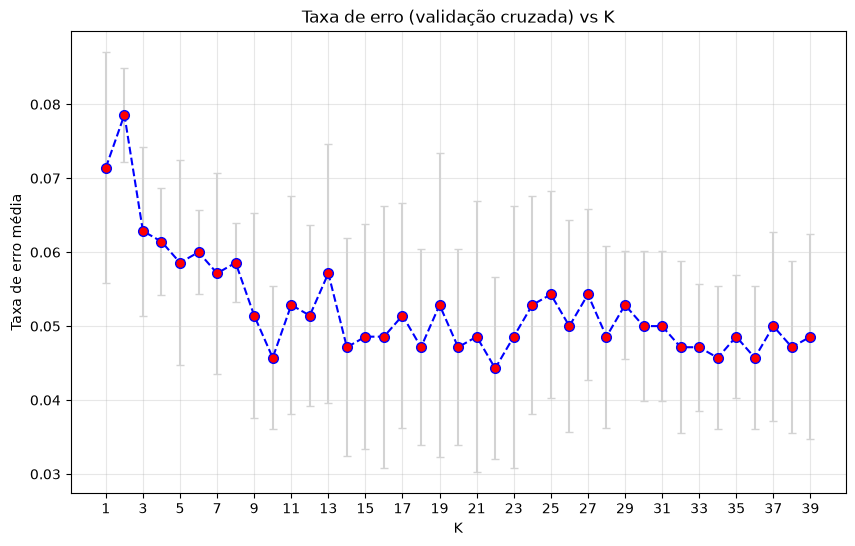

     K  erro_medio  desvio
21  22      0.0443  0.0123
9   10      0.0457  0.0097
35  36      0.0457  0.0097
33  34      0.0457  0.0097
31  32      0.0471  0.0116


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

k_values = range(1, 40)
mean_error = []
std_error = []

for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    mean_error.append(1 - scores.mean())
    std_error.append(scores.std())

# gráfico: taxa de erro (CV) vs K
plt.figure(figsize=(10, 6))
plt.errorbar(k_values, mean_error, yerr=std_error, fmt='o--', color='blue',
             ecolor='lightgray', markerfacecolor='red', markersize=7, capsize=3)
plt.title('Taxa de erro (validação cruzada) vs K')
plt.xlabel('K')
plt.ylabel('Taxa de erro média')
plt.xticks(range(1, 40, 2))
plt.grid(alpha=0.3)
plt.show()

# os 5 menores erros
resultado = pd.DataFrame({'K': list(k_values), 'erro_medio': mean_error, 'desvio': std_error})
print(resultado.sort_values('erro_medio').head(5).round(4))

# Modelo final: K escolhido por validação cruzada

In [31]:
k_final = 23

pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=k_final))
])

# o Pipeline recebe X_train SEM padronizar: o scaler é ajustado só no treino
pipe_final.fit(X_train, y_train)
pred_final = pipe_final.predict(X_test)

print(f"WITH K={k_final}\n")
print("Matriz de confusão:")
print(confusion_matrix(y_test, pred_final))

print("\nClassification report:")
print(classification_report(y_test, pred_final))

# comparação: erro da validação cruzada vs erro no teste vs baseline
erro_cv = mean_error[k_final - 1]
erro_teste = np.mean(pred_final != y_test)
erro_k1 = np.mean(pred1 != y_test)

print(f"Erro CV (K={k_final}):    {erro_cv:.4f}")
print(f"Erro no teste (K={k_final}): {erro_teste:.4f}")
print(f"Erro no teste (K=1):    {erro_k1:.4f}")

WITH K=23

Matriz de confusão:
[[136  14]
 [  8 142]]

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       150
           1       0.91      0.95      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300

Erro CV (K=23):    0.0486
Erro no teste (K=23): 0.0733
Erro no teste (K=1):    0.1033
